In [1]:
!pip install -q gdown

In [25]:
!gdown "https://drive.google.com/uc?export=download&id=1hRNI7bcK7gKrbecYsa51IYLkimgzDhCc" -O ./mydata

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1hRNI7bcK7gKrbecYsa51IYLkimgzDhCc
From (redirected): https://drive.google.com/uc?export=download&id=1hRNI7bcK7gKrbecYsa51IYLkimgzDhCc&confirm=t&uuid=f5402a01-4f25-417a-a75b-70eb97f1c447
To: /content/mydata
100% 2.94G/2.94G [00:46<00:00, 63.6MB/s]


In [26]:
import os

file_path = '/content/mydata'
if os.path.exists(file_path):
    # Use the 'file' command to determine the file type
    !file -b --mime-type {file_path}
else:
    print(f"File not found at {file_path}")

application/zip


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import zipfile
from google.colab import drive

In [27]:
DRIVE_ZIP_PATH = '/content/mydata' # Path to your zip file on Google Drive
EXTRACT_PATH = '/content/dataset'                    # Local Colab path to unzip data
BATCH_SIZE = 4                                       # Batch size for testing the loader

# --- 2. Data Extraction Function ---

def extract_data(zip_path, extract_path):
    """
    Mounts Google Drive and extracts the dataset zip file to the local
    Colab runtime environment for faster access.
    """
    try:

        # Check if zip file exists
        if not os.path.exists(zip_path):
            print(f"ERROR: Zip file not found at {zip_path}")
            print("Please check the path in DRIVE_ZIP_PATH.")
            return False

        # Extract data
        if not os.path.exists(extract_path) or not os.listdir(extract_path):
            print(f"Extracting dataset from {zip_path} to {extract_path}...")
            os.makedirs(extract_path, exist_ok=True)
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path)
            print("Extraction complete.")
        else:
            print("Dataset already extracted.")
        return True
    except Exception as e:
        print(f"An error occurred during extraction: {e}")
        return False

In [28]:
# --- 3. Custom PyTorch Dataset Class ---

class DeepGlobeDataset(Dataset):
    """
    Custom Dataset for DeepGlobe. Loads satellite images and converts
    RGB masks to single-channel integer masks.
    """
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # Find all satellite images, assuming they are in the root of image_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('_sat.jpg')])

        # Define the critical mapping from RGB color to Class ID
        self.rgb_to_id = {
            (0, 255, 255): 0,   # urban_land
            (255, 255, 0): 1,   # agriculture_land
            (255, 0, 255): 2,   # rangeland
            (0, 255, 0): 3,     # forest_land
            (0, 0, 255): 4,     # water
            (255, 255, 255): 5, # barren_land
            (0, 0, 0): 6        # unknown
        }

        # Precompute a lookup table for faster mask conversion
        # Initialize with the 'unknown' class ID (6)
        self.mask_lookup_table = np.full((256, 256, 256), fill_value=6, dtype=np.int64)
        for rgb_tuple, class_id in self.rgb_to_id.items():
            r, g, b = rgb_tuple
            self.mask_lookup_table[r, g, b] = class_id

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and mask paths
        img_name = self.images[idx]
        mask_name = img_name.replace('_sat.jpg', '_mask.png')
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask_rgb = Image.open(mask_path).convert("RGB")

        image_np = np.array(image)
        mask_rgb_np = np.array(mask_rgb)

        # --- Optimized Core Conversion Logic ---
        # Use the precomputed lookup table for direct mapping
        mask_int = self.mask_lookup_table[mask_rgb_np[:, :, 0],
                                          mask_rgb_np[:, :, 1],
                                          mask_rgb_np[:, :, 2]]

        # Apply transforms (e.g., augmentations) if provided
        if self.transform:
            augmented = self.transform(image=image_np, mask=mask_int)
            image_np = augmented['image']
            mask_int = augmented['mask']

        # Convert to Tensors
        # Normalize image to [0, 1] and set format to [C, H, W]
        image_tensor = torch.from_numpy(image_np.transpose((2, 0, 1))).float() / 255.0
        # Convert mask to LongTensor [H, W]
        mask_tensor = torch.from_numpy(mask_int).long()

        return image_tensor, mask_tensor

In [29]:
# --- 4. Verification Functions ---

def verify_mask_conversion(mask_dir):
    """
    Loads one mask and plots the original RGB vs. the processed integer
    mask to visually verify the conversion.
    """
    print("\n--- Verifying Mask Conversion ---")
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('_mask.png')]
    if not mask_files:
        print(f"ERROR: No mask files found in {mask_dir}")
        return

    test_mask_name = mask_files[0]
    mask_path = os.path.join(mask_dir, test_mask_name)

    # Load original RGB mask
    mask_rgb_np = np.array(Image.open(mask_path).convert("RGB"))

    # Define the critical mapping from RGB color to Class ID
    rgb_to_id_map = {
        (0, 255, 255): 0, (255, 255, 0): 1, (255, 0, 255): 2,
        (0, 255, 0): 3, (0, 0, 255): 4, (255, 255, 255): 5, (0, 0, 0): 6
    }

    # Precompute a lookup table for faster mask conversion within verification
    mask_lookup_table = np.full((256, 256, 256), fill_value=6, dtype=np.int64)
    for rgb_tuple, class_id in rgb_to_id_map.items():
        r, g, b = rgb_tuple
        mask_lookup_table[r, g, b] = class_id

    # --- Optimized Re-run the conversion logic manually ---
    mask_int_np = mask_lookup_table[mask_rgb_np[:, :, 0],
                                    mask_rgb_np[:, :, 1],
                                    mask_rgb_np[:, :, 2]]

    # --- Plotting ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(mask_rgb_np)
    ax[0].set_title(f"Original RGB Mask\nShape: {mask_rgb_np.shape}")
    ax[0].axis('off')

    im = ax[1].imshow(mask_int_np, cmap='tab10', vmin=0, vmax=6)
    ax[1].set_title(f"Processed Integer Mask\nShape: {mask_int_np.shape}")
    ax[1].axis('off')

    fig.colorbar(im, ax=ax[1], ticks=range(7), orientation='vertical')
    plt.tight_layout()
    plt.savefig("mask_conversion_check.png")
    print("Verification plot saved to 'mask_conversion_check.png'")
    plt.show()

In [30]:
def verify_dataloader(dataset):
    """
    Checks the output of the DataLoader to confirm batch shapes and data types.
    """
    print("\n--- Verifying DataLoader ---")
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    images, masks = next(iter(loader))

    print(f"Images batch shape: {images.shape}")
    print(f"Images batch dtype: {images.dtype}")
    print(f"Images min/max:   {images.min()}, {images.max()}")
    print(f"Masks batch shape:  {masks.shape}")
    print(f"Masks batch dtype:  {masks.dtype}")
    print(f"Unique values in masks: {torch.unique(masks)}")
    print("DataLoader check passed.")

Extracting dataset from /content/mydata to /content/dataset...
Extraction complete.

--- Verifying Mask Conversion ---
Verification plot saved to 'mask_conversion_check.png'


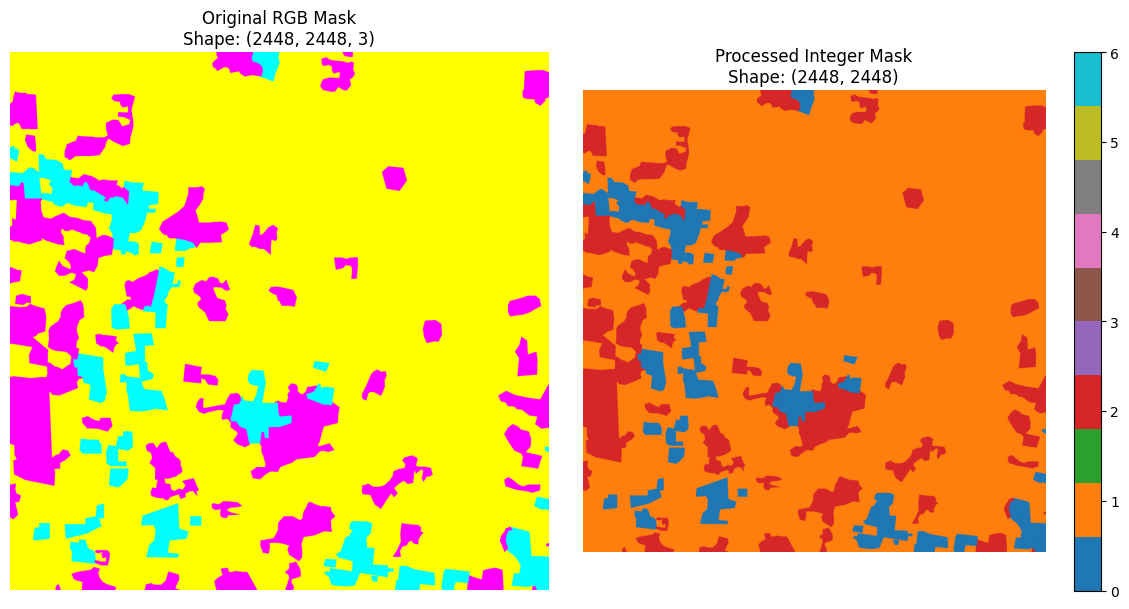


--- Verifying DataLoader ---
Images batch shape: torch.Size([4, 3, 2448, 2448])
Images batch dtype: torch.float32
Images min/max:   0.0, 1.0
Masks batch shape:  torch.Size([4, 2448, 2448])
Masks batch dtype:  torch.int64
Unique values in masks: tensor([0, 1, 2, 3, 4, 5, 6])
DataLoader check passed.

Preprocessing pipeline setup and verification complete.


In [31]:
# --- 5. Main Execution Block ---

if __name__ == "__main__":
    # This block will run when you execute the cell in Colab

    # Step 1: Extract the data
    if extract_data(DRIVE_ZIP_PATH, EXTRACT_PATH):

        # Step 2: Define dataset paths (adjust if your zip file has a different structure)
        # Assumes data is in /content/dataset/train/
        TRAIN_DIR = os.path.join(EXTRACT_PATH, "train")

        # Check if the 'train' directory exists
        if not os.path.exists(TRAIN_DIR):
            print(f"ERROR: 'train' directory not found in {EXTRACT_PATH}")
            print("Please check your zip file structure and update TRAIN_DIR.")
        else:
            # In the DeepGlobe dataset, images and masks are in the same folder
            TRAIN_IMG_DIR = TRAIN_DIR
            TRAIN_MASK_DIR = TRAIN_DIR

            # Step 3: Verify the mask conversion
            verify_mask_conversion(TRAIN_MASK_DIR)

            # Step 4: Verify the DataLoader
            train_dataset = DeepGlobeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR)

            if len(train_dataset) > 0:
                verify_dataloader(train_dataset)
                print("\nPreprocessing pipeline setup and verification complete.")
            else:
                print(f"ERROR: No images found in {TRAIN_IMG_DIR}. Cannot verify DataLoader.")



--- Creating Presentation Visualization ---

Visualization saved to 'BTP_Review_Visualization.png'


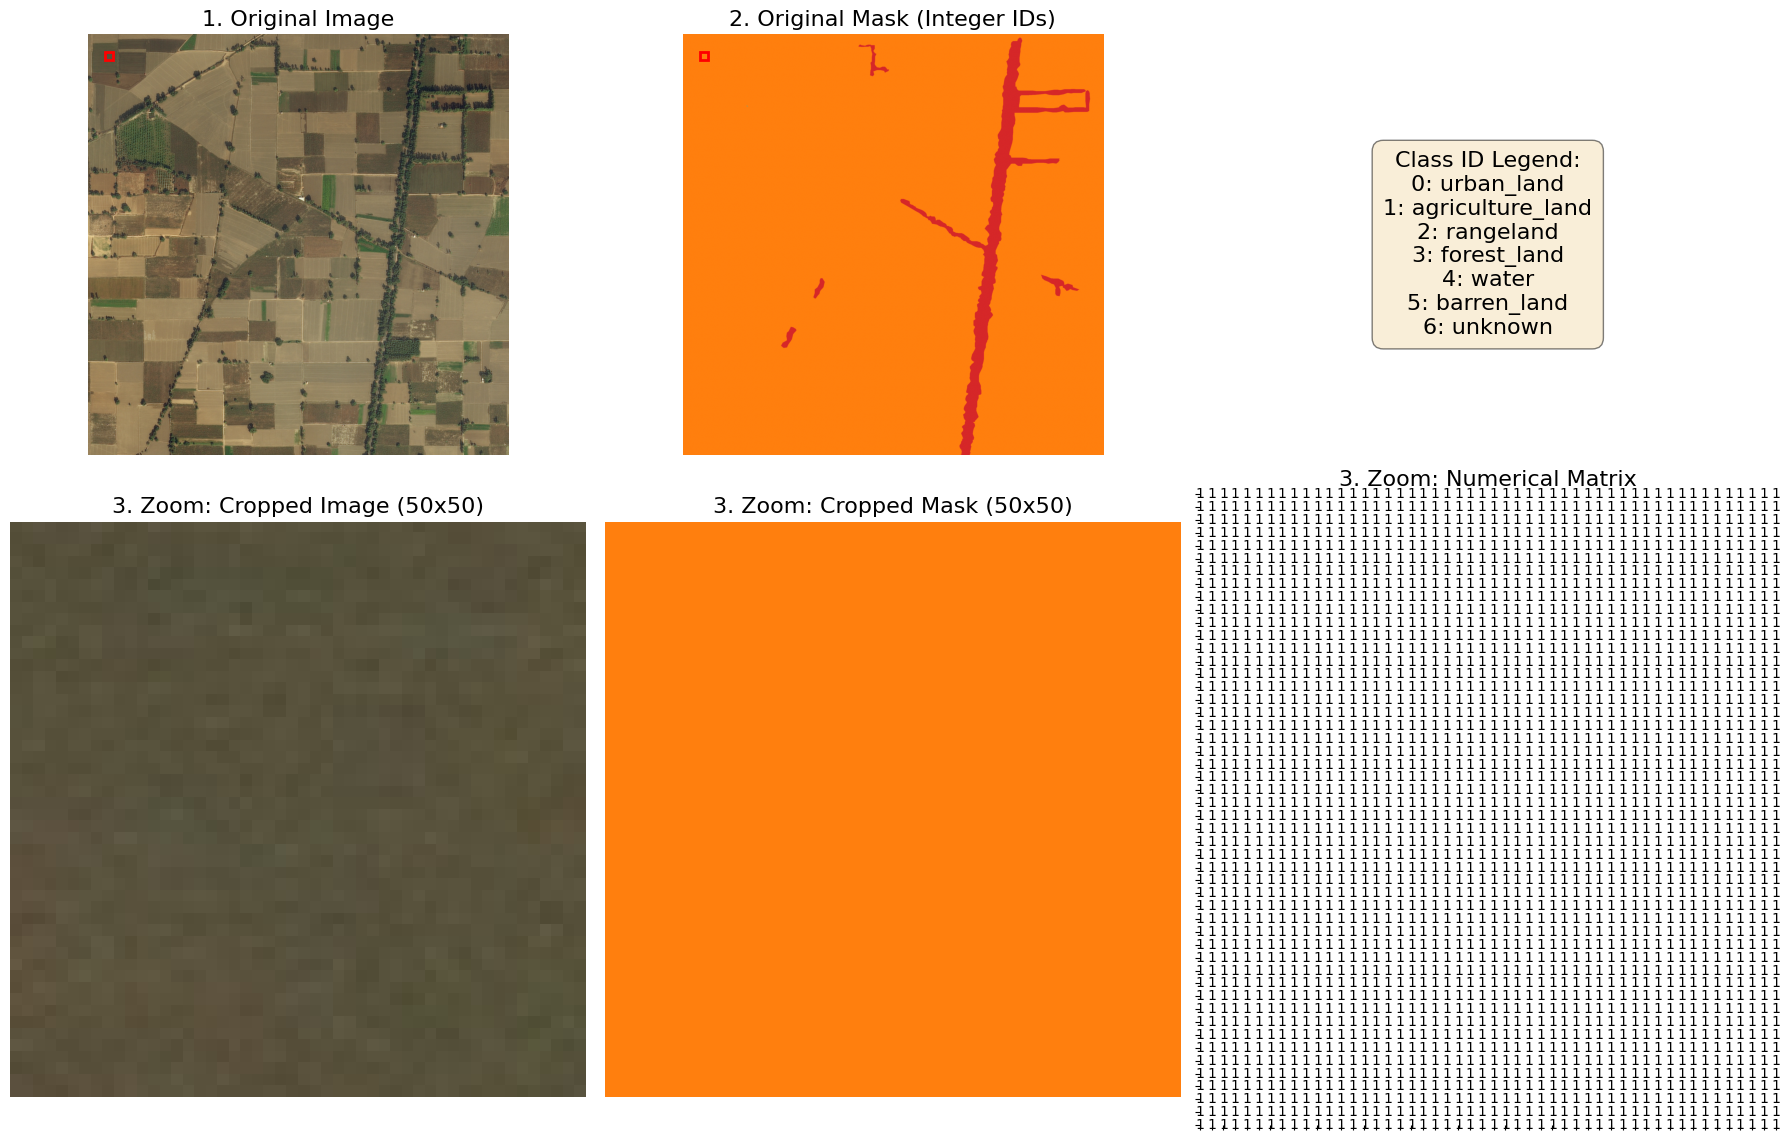

In [32]:
import matplotlib.gridspec as gridspec

# Define a reverse mapping from ID to Class Name for the legend
id_to_name = {
    0: "urban_land",
    1: "agriculture_land",
    2: "rangeland",
    3: "forest_land",
    4: "water",
    5: "barren_land",
    6: "unknown"
}


def create_presentation_visual():
    """
    Generates a multi-panel visualization suitable for a presentation,
    showing an image, its mask, a zoomed-in section of both, and a
    numerical representation of the zoomed mask.
    """
    print("\n--- Creating Presentation Visualization ---")
    try:
        # Load one example from the dataset
        train_dataset = DeepGlobeDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR)
        if len(train_dataset) == 0:
            print("ERROR: Dataset is empty. Cannot create visualization.")
            return

        image_tensor, mask_tensor = train_dataset[0] # Get the first sample

        # Convert tensors to numpy arrays for plotting
        image_np = image_tensor.permute(1, 2, 0).numpy() # Change from [C, H, W] to [H, W, C]
        mask_int = mask_tensor.numpy()

        # Define crop size and coordinates (adjust as needed)
        CROP_SIZE = 50
        start_row = 100 # Example start row
        start_col = 100 # Example start column
        end_row = start_row + CROP_SIZE
        end_col = start_col + CROP_SIZE

        # Ensure crop is within bounds
        if end_row > image_np.shape[0] or end_col > image_np.shape[1]:
             print(f"ERROR: Crop area is out of bounds. Image shape: {image_np.shape[:2]}")
             return

        # Crop the image and mask
        cropped_image = image_np[start_row:end_row, start_col:end_col]
        cropped_int = mask_int[start_row:end_row, start_col:end_col]

        # Setup the figure and grid layout
        fig = plt.figure(figsize=(18, 12))
        gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1, 1.5], width_ratios=[1, 1, 1])

        # Panel 1: Original Image
        ax_img = fig.add_subplot(gs[0, 0])
        ax_img.imshow(image_np)
        ax_img.set_title('1. Original Image', fontsize=16)
        ax_img.axis('off')

        # Panel 2: Original Mask
        ax_mask = fig.add_subplot(gs[0, 1])
        # Use a colormap that clearly distinguishes classes
        im_mask = ax_mask.imshow(mask_int, cmap='tab10', vmin=0, vmax=6)
        ax_mask.set_title('2. Original Mask (Integer IDs)', fontsize=16)
        ax_mask.axis('off')

        # Panel 3: Zoomed Image
        ax_zoom_img = fig.add_subplot(gs[1, 0])
        ax_zoom_img.imshow(cropped_image)
        ax_zoom_img.set_title(f'3. Zoom: Cropped Image ({CROP_SIZE}x{CROP_SIZE})', fontsize=16)
        ax_zoom_img.axis('off')
        # Add a rectangle to the original image to show the zoomed area
        rect = plt.Rectangle((start_col, start_row), CROP_SIZE, CROP_SIZE,
                             linewidth=2, edgecolor='r', facecolor='none')
        ax_img.add_patch(rect)


        # Panel 4: Zoomed Mask
        ax_zoom_mask = fig.add_subplot(gs[1, 1])
        im_zoom_mask = ax_zoom_mask.imshow(cropped_int, cmap='tab10', vmin=0, vmax=6)
        ax_zoom_mask.set_title(f'3. Zoom: Cropped Mask ({CROP_SIZE}x{CROP_SIZE})', fontsize=16)
        ax_zoom_mask.axis('off')
        # Add a rectangle to the original mask to show the zoomed area
        rect_mask = plt.Rectangle((start_col, start_row), CROP_SIZE, CROP_SIZE,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax_mask.add_patch(rect_mask)


        # Panel 5: Numerical Matrix of Zoomed Mask
        ax_matrix = fig.add_subplot(gs[1, 2])
        ax_matrix.set_title(f'3. Zoom: Numerical Matrix', fontsize=16)
        for i in range(CROP_SIZE):
            for j in range(CROP_SIZE):
                ax_matrix.text(j, i, str(cropped_int[i, j]), ha="center", va="center", color="black", fontsize=10)
        ax_matrix.set_xticks(np.arange(CROP_SIZE)), ax_matrix.set_yticks(np.arange(CROP_SIZE))
        ax_matrix.set_xticklabels([]), ax_matrix.set_yticklabels([])
        ax_matrix.grid(which="both", color='w', linestyle='-', linewidth=2)
        ax_matrix.set_frame_on(False)

        # Legend
        legend_text = "Class ID Legend:\n" + "\n".join([f"{k}: {v}" for k, v in id_to_name.items()])
        ax_legend = fig.add_subplot(gs[0, 2]) # Adjusted position for legend
        ax_legend.text(0.5, 0.5, legend_text, ha='center', va='center', fontsize=16,
                       bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5))
        ax_legend.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig("BTP_Review_Visualization.png", dpi=150)
        print("\nVisualization saved to 'BTP_Review_Visualization.png'")
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")

# --- 5. Run the Visualization ---
if __name__ == "__main__":
    create_presentation_visual()

In [33]:
import os
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

# ---- (A) Albumentations transforms (with safe fallback) ----
try:
    import albumentations as A
    HAS_ALBU = True
except Exception:
    HAS_ALBU = False
    A = None

In [34]:
def build_transforms(image_size=512, augment=True):
    if HAS_ALBU:
        aug = []
        if augment:
            aug += [
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
            ]
        aug += [A.Resize(image_size, image_size, interpolation=1)]  # cv2.INTER_LINEAR
        return A.Compose(aug)
    else:
        # Fallback: resize via PIL and return dict-like
        class _Fallback:
            def __init__(self, size): self.size = size
            def __call__(self, image, mask):
                image = np.array(Image.fromarray(image).resize((self.size, self.size), Image.BILINEAR))
                mask  = np.array(Image.fromarray(mask).resize((self.size, self.size), Image.NEAREST), dtype=np.int64)
                return {"image": image, "mask": mask}
        return _Fallback(image_size)

In [35]:
# ---- (B) U-Net definition ----
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

In [36]:
class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # pad to match (handles odd dims)
        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.conv(x)

In [37]:
class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.conv(x)

In [38]:
class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=7, bilinear=True, base_ch=64):
        super().__init__()
        self.inc   = DoubleConv(n_channels, base_ch)
        self.down1 = Down(base_ch, base_ch*2)
        self.down2 = Down(base_ch*2, base_ch*4)
        self.down3 = Down(base_ch*4, base_ch*8)
        factor = 2 if bilinear else 1
        self.down4 = Down(base_ch*8, (base_ch*16)//factor)
        self.up1   = Up(base_ch*16, base_ch*8//factor, bilinear)
        self.up2   = Up(base_ch*8,  base_ch*4//factor, bilinear)
        self.up3   = Up(base_ch*4,  base_ch*2//factor, bilinear)
        self.up4   = Up(base_ch*2,  base_ch,          bilinear)
        self.outc  = OutConv(base_ch, n_classes)
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x  = self.up1(x5, x4)
        x  = self.up2(x,  x3)
        x  = self.up3(x,  x2)
        x  = self.up4(x,  x1)
        return self.outc(x)

In [39]:
# ---- (C) Metrics and Losses ----
def compute_confusion_matrix(pred, target, num_classes):
    with torch.no_grad():
        k = (target >= 0) & (target < num_classes)
        inds = num_classes * target[k] + pred[k]
        cm = torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes)
    return cm

def miou_from_confmat(confmat):
    with torch.no_grad():
        tp = torch.diag(confmat).float()
        denom = confmat.sum(1) + confmat.sum(0) - tp
        iou = tp / torch.clamp(denom, min=1.0)
        return float(iou.mean().item())

In [40]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1.0, ignore_index=None):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ignore_index = ignore_index
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        one_hot = F.one_hot(torch.clamp(targets, min=0), num_classes=self.num_classes).permute(0,3,1,2).float()
        if self.ignore_index is not None:
            mask = (targets != self.ignore_index).unsqueeze(1).float()
            probs = probs * mask
            one_hot = one_hot * mask
        dims = (0,2,3)
        inter = torch.sum(probs * one_hot, dims)
        card  = torch.sum(probs + one_hot, dims)
        dice  = (2. * inter + self.smooth) / (card + self.smooth)
        return 1 - dice.mean()

In [41]:
# ---- (D) Train & Eval loops ----
def train_one_epoch(model, loader, optimizer, ce_loss, dice_loss, device, num_classes):
    model.train()
    total_loss = 0.0
    conf = torch.zeros((num_classes, num_classes), dtype=torch.long, device=device)
    for imgs, masks in loader:
        imgs  = imgs.to(device, non_blocking=True).float()
        masks = masks.to(device, non_blocking=True).long()

        logits = model(imgs)
        loss = ce_loss(logits, masks) + dice_loss(logits, masks)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            conf += compute_confusion_matrix(preds, masks, num_classes)
    return total_loss / len(loader.dataset), miou_from_confmat(conf)

In [42]:
import os
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

# ---- (A) Albumentations transforms (with safe fallback) ----
try:
    import albumentations as A
    HAS_ALBU = True
except Exception:
    HAS_ALBU = False
    A = None

# ---- (D) Train & Eval loops ----
def train_one_epoch(model, loader, optimizer, ce_loss, dice_loss, device, num_classes):
    model.train()
    total_loss = 0.0
    conf = torch.zeros((num_classes, num_classes), dtype=torch.long, device=device)
    for imgs, masks in loader:
        imgs  = imgs.to(device, non_blocking=True).float()
        masks = masks.to(device, non_blocking=True).long()

        logits = model(imgs)
        loss = ce_loss(logits, masks) + dice_loss(logits, masks)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            conf += compute_confusion_matrix(preds, masks, num_classes)
    # Fix: Access the dataset attribute from the original DataLoader object wrapped by tqdm
    return total_loss / len(loader.iterable.dataset), miou_from_confmat(conf)

@torch.no_grad()
def evaluate(model, loader, ce_loss, dice_loss, device, num_classes):
    model.eval()
    total_loss = 0.0
    conf = torch.zeros((num_classes, num_classes), dtype=torch.long, device=device)
    for imgs, masks in loader:
        imgs  = imgs.to(device, non_blocking=True).float()
        masks = masks.to(device, non_blocking=True).long()

        logits = model(imgs)
        loss = ce_loss(logits, masks) + dice_loss(logits, masks)
        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        conf += compute_confusion_matrix(preds, masks, num_classes)
    # Fix: Access the dataset attribute from the original DataLoader object wrapped by tqdm
    return total_loss / len(loader.iterable.dataset), miou_from_confmat(conf)

# ---- (E) Build datasets/dataloaders using YOUR DeepGlobeDataset ----
# Uses the same TRAIN_IMG_DIR and TRAIN_MASK_DIR you already set in preprocessing.
IMAGE_DIR = TRAIN_IMG_DIR
MASK_DIR  = TRAIN_MASK_DIR
NUM_CLASSES = 7
IMAGE_SIZE = 512
BATCH_SIZE = 4
EPOCHS = 30
LR = 3e-4
NUM_WORKERS = 0 # Changed from 2 to 0 for debugging silent DataLoader issues
VAL_SPLIT = 0.15
CKPT_PATH = "/content/unet_deepglobe.pt"


In [43]:
train_tf = build_transforms(IMAGE_SIZE, augment=True)
val_tf   = build_transforms(IMAGE_SIZE, augment=False)

# full dataset (reusing your class)
full_ds = DeepGlobeDataset(IMAGE_DIR, MASK_DIR, transform=None)  # base instance to get indices

# Do a deterministic split
n = len(full_ds)
n_val = max(1, int(n * VAL_SPLIT))
n_tr = n - n_val
rng = np.random.default_rng(42)
perm = rng.permutation(n)
tr_idx, va_idx = perm[:n_tr], perm[n_tr:]

In [44]:
# Build two dataset instances with different transforms
train_ds = DeepGlobeDataset(IMAGE_DIR, MASK_DIR, transform=train_tf)
val_ds   = DeepGlobeDataset(IMAGE_DIR, MASK_DIR, transform=val_tf)

train_subset = Subset(train_ds, tr_idx.tolist())
val_subset   = Subset(val_ds, va_idx.tolist())

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [45]:
# ---- (F) Train ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(n_channels=3, n_classes=NUM_CLASSES, bilinear=True, base_ch=64).to(device)
ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss(num_classes=NUM_CLASSES, ignore_index=None)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

In [46]:
from tqdm.notebook import tqdm # Import tqdm for progress bar

best_miou = -1.0
for ep in range(1, EPOCHS + 1):
    print(f"\n--- Epoch {ep:03d}/{EPOCHS} ---")
    tr_loss, tr_miou = train_one_epoch(model, tqdm(train_loader, desc=f"Training Epoch {ep}"), optimizer, ce_loss, dice_loss, device, NUM_CLASSES)
    va_loss, va_miou = evaluate(model, tqdm(val_loader, desc=f"Validation Epoch {ep}"), ce_loss, dice_loss, device, NUM_CLASSES)
    print(f"Epoch {ep:03d}/{EPOCHS} | Train: loss {tr_loss:.4f} mIoU {tr_miou:.4f} | Val: loss {va_loss:.4f} mIoU {va_miou:.4f}")
    if va_miou > best_miou:
        best_miou = va_miou
        torch.save({"epoch": ep, "model": model.state_dict(), "optimizer": optimizer.state_dict()}, CKPT_PATH)
        print(f"  Saved best checkpoint to {CKPT_PATH} (mIoU={best_miou:.4f})")

print("Training complete.")


--- Epoch 001/30 ---


Training Epoch 1:   0%|          | 0/171 [00:00<?, ?it/s]

Validation Epoch 1:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 001/30 | Train: loss 2.1978 mIoU 0.1881 | Val: loss 1.7751 mIoU 0.2648
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.2648)

--- Epoch 002/30 ---


Training Epoch 2:   0%|          | 0/171 [00:00<?, ?it/s]

...

Training Epoch 12:   0%|          | 0/171 [00:00<?, ?it/s]

Validation Epoch 12:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 012/30 | Train: loss 1.5063 mIoU 0.3572 | Val: loss 1.4186 mIoU 0.4130

--- Epoch 013/30 ---


Training Epoch 13:   0%|          | 0/171 [00:00<?, ?it/s]

KeyboardInterrupt: 

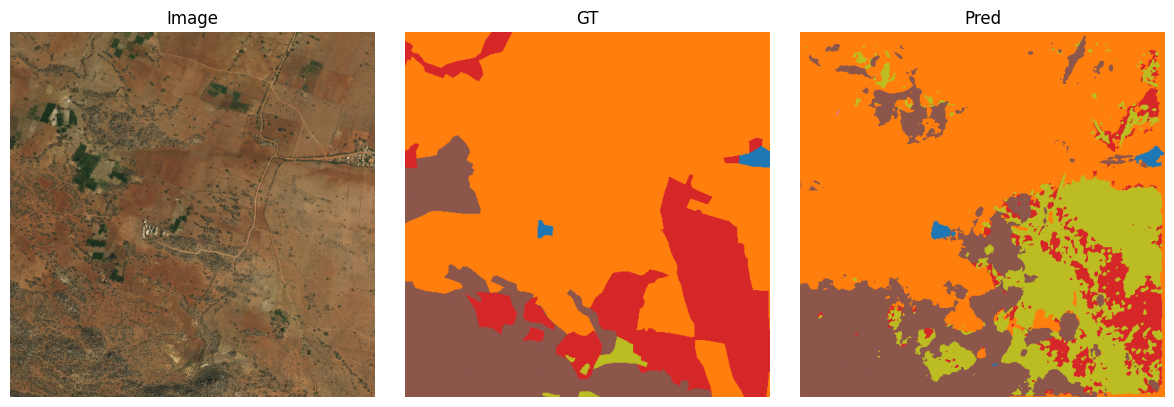

In [48]:
# ---- (G) Quick visual preview on a few val samples ----
try:
    import matplotlib.pyplot as plt
    model.eval()
    imgs, msks = next(iter(val_loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        preds = torch.argmax(model(imgs), dim=1).cpu().numpy()
    img0 = (imgs[0].cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
    msk0 = msks[0].cpu().numpy()
    prd0 = preds[0]

    fig, ax = plt.subplots(1,3, figsize=(12,4))
    ax[0].imshow(img0); ax[0].set_title("Image"); ax[0].axis("off")
    ax[1].imshow(msk0, cmap="tab10", vmin=0, vmax=NUM_CLASSES-1); ax[1].set_title("GT"); ax[1].axis("off")
    ax[2].imshow(prd0, cmap="tab10", vmin=0, vmax=NUM_CLASSES-1); ax[2].set_title("Pred"); ax[2].axis("off")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Preview skipped: {e}")

In [56]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Regex to extract epoch, train_loss, train_miou, val_loss, val_miou
log_pattern = re.compile(r"Epoch (\d+)/\d+\s\| Train: loss (\d+\.\d+) mIoU (\d+\.\d+)\s\| Val: loss (\d+\.\d+) mIoU (\d+\.\d+)")

# Get the output from the training cell (w9n7kM0vsbAJ)
training_output = """
--- Epoch 001/30 ---

Epoch 001/30 | Train: loss 2.1978 mIoU 0.1881 | Val: loss 1.7751 mIoU 0.2648
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.2648)

--- Epoch 002/30 ---

Epoch 002/30 | Train: loss 1.8875 mIoU 0.2100 | Val: loss 1.7976 mIoU 0.2719
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.2719)

--- Epoch 003/30 ---

Epoch 003/30 | Train: loss 1.7855 mIoU 0.2463 | Val: loss 1.7939 mIoU 0.2801
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.2801)

--- Epoch 004/30 ---

Epoch 004/30 | Train: loss 1.7626 mIoU 0.2631 | Val: loss 1.6723 mIoU 0.3243
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.3243)

--- Epoch 005/30 ---

Epoch 005/30 | Train: loss 1.6801 mIoU 0.2912 | Val: loss 1.5196 mIoU 0.3939
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.3939)

--- Epoch 006/30 ---

Epoch 006/30 | Train: loss 1.6443 mIoU 0.3093 | Val: loss 1.4898 mIoU 0.3955
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.3955)

--- Epoch 007/30 ---

Epoch 007/30 | Train: loss 1.6135 mIoU 0.3186 | Val: loss 1.4633 mIoU 0.3991
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.3991)

--- Epoch 008/30 ---

Epoch 008/30 | Train: loss 1.5876 mIoU 0.3308 | Val: loss 1.4435 mIoU 0.4095
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.4095)

--- Epoch 009/30 ---

Epoch 009/30 | Train: loss 1.5989 mIoU 0.3266 | Val: loss 1.6961 mIoU 0.3548

--- Epoch 010/30 ---

Epoch 010/30 | Train: loss 1.5244 mIoU 0.3442 | Val: loss 1.4811 mIoU 0.3724

--- Epoch 011/30 ---

Epoch 011/30 | Train: loss 1.5122 mIoU 0.3503 | Val: loss 1.4138 mIoU 0.4132
  Saved best checkpoint to /content/unet_deepglobe.pt (mIoU=0.4132)

--- Epoch 012/30 ---
"""

data = []
for line in training_output.splitlines():
    match = log_pattern.match(line)
    if match:
        epoch, tr_loss, tr_miou, va_loss, va_miou = map(float, match.groups())
        data.append({
            'Epoch': int(epoch),
            'Train Loss': tr_loss,
            'Train mIoU': tr_miou,
            'Validation Loss': va_loss,
            'Validation mIoU': va_miou
        })

df_metrics = pd.DataFrame(data)
display(df_metrics.head())


,Epoch,Train Loss,Train mIoU,Validation Loss,Validation mIoU
0,1,2.1978,0.1881,1.7751,0.2648
1,2,1.8875,0.2100,1.7976,0.2719
2,3,1.7855,0.2463,1.7939,0.2801
3,4,1.7626,0.2631,1.6723,0.3243
4,5,1.6801,0.2912,1.5196,0.3939


In [57]:
display(df_metrics)

,Epoch,Train Loss,Train mIoU,Validation Loss,Validation mIoU
0,1,2.1978,0.1881,1.7751,0.2648
1,2,1.8875,0.2100,1.7976,0.2719
2,3,1.7855,0.2463,1.7939,0.2801
3,4,1.7626,0.2631,1.6723,0.3243
4,5,1.6801,0.2912,1.5196,0.3939
5,6,1.6443,0.3093,1.4898,0.3955
6,7,1.6135,0.3186,1.4633,0.3991
7,8,1.5876,0.3308,1.4435,0.4095
8,9,1.5989,0.3266,1.6961,0.3548
9,10,1.5244,0.3442,1.4811,0.3724


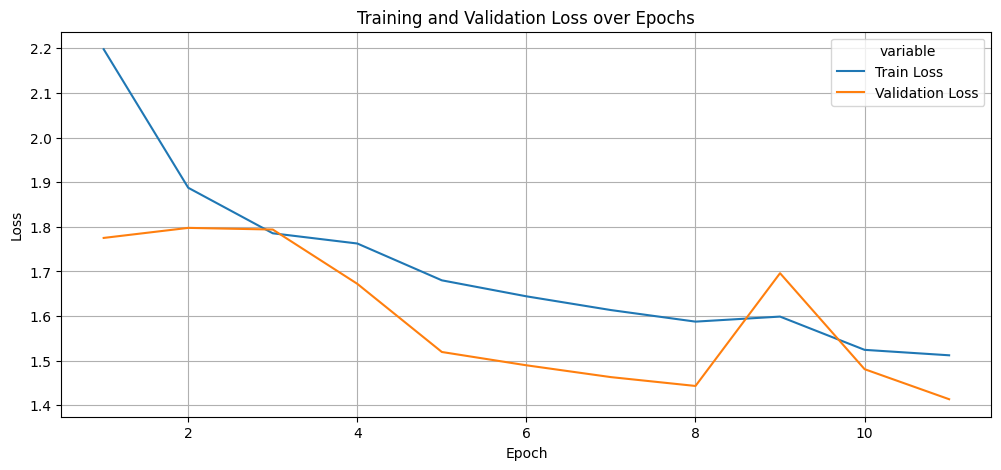

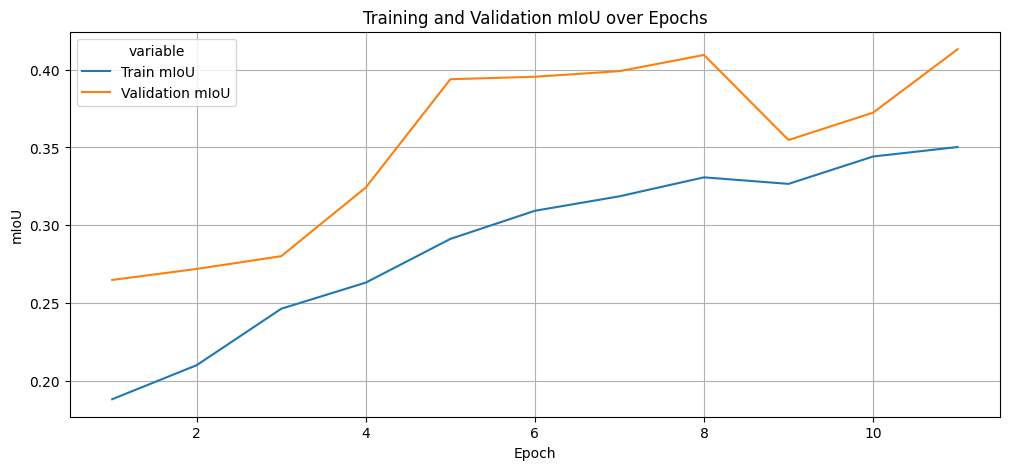

In [54]:
# Plotting Loss
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='value', hue='variable', data=pd.melt(df_metrics, ['Epoch'], value_vars=['Train Loss', 'Validation Loss']))
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Plotting mIoU
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='value', hue='variable', data=pd.melt(df_metrics, ['Epoch'], value_vars=['Train mIoU', 'Validation mIoU']))
plt.title('Training and Validation mIoU over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.grid(True)
plt.show()